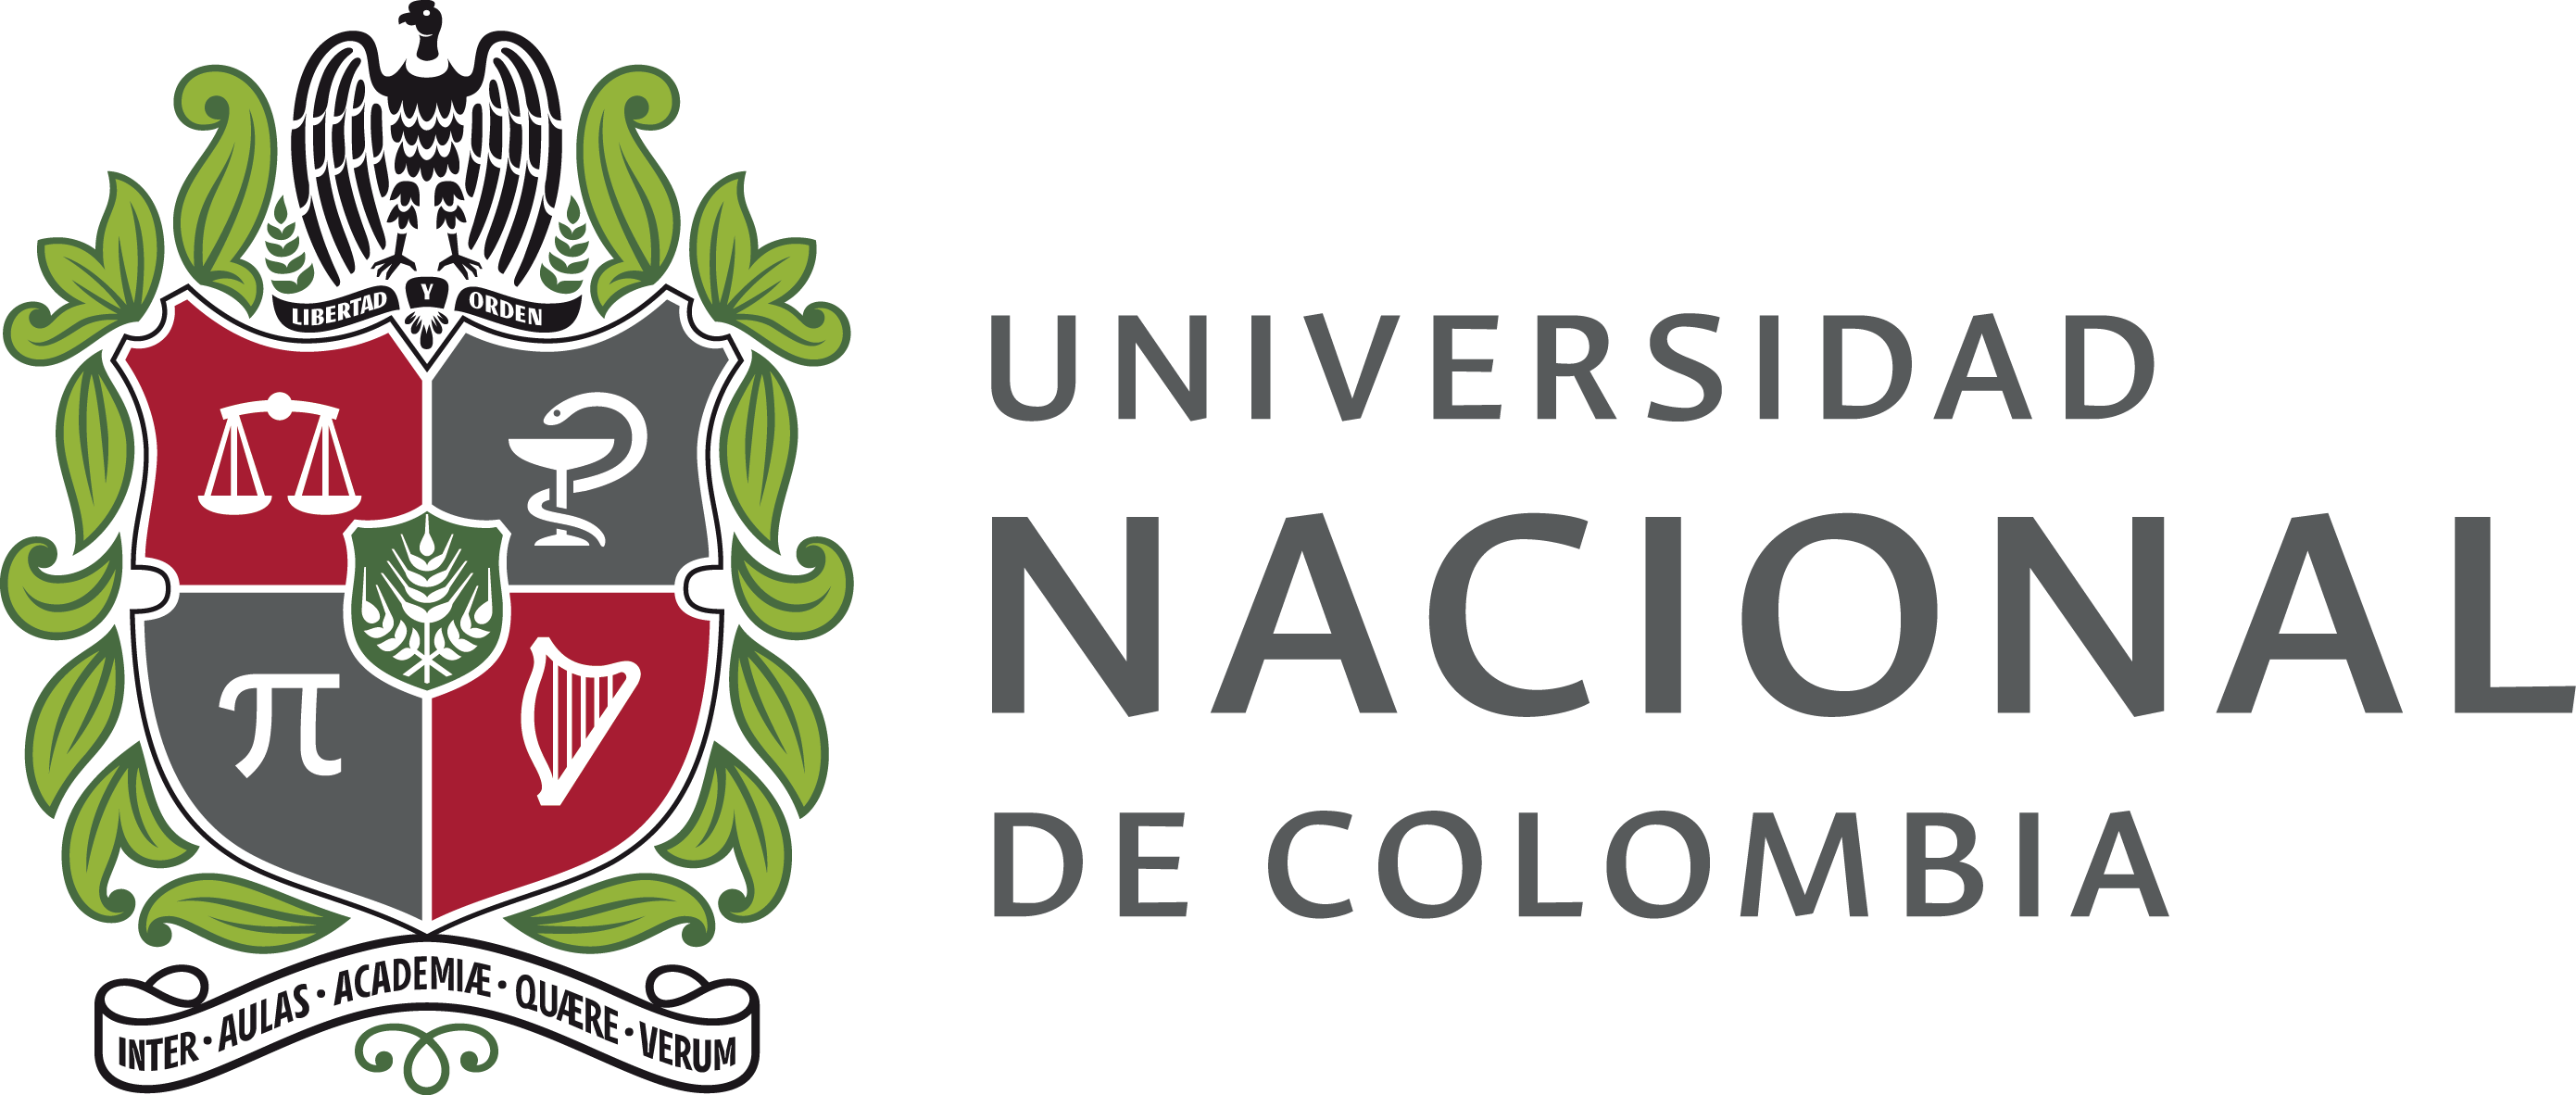
### **Universidad Nacional de Colombia sede Manizales**
#### Facultad de ingeniería y arquitectura
#### Departamento de ingeniería eléctrica, electrónica y computación
#### *Procesamiento digital de imágenes*

#### Profesor: Lucas Iturriago

### Instalar bibliotecas de Python

In [1]:
%%capture
!pip install roboflow

### Importar bibliotecas de Python

In [2]:
import os
import re
import glob
import time
import random
import numpy as np
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from roboflow import Roboflow
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from keras.saving import register_keras_serializable

2025-12-02 06:16:50.311456: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764656210.741394      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764656210.871628      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

### Descargar base de datos

In [3]:
rf = Roboflow(api_key="9smAmQgaD8pNOTsDMYKR")
project = rf.workspace("semantic-segmentation-844lw").project("raccoon-detection-cgctv")
version = project.version(5)
dataset = version.download("png-mask-semantic")           

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Raccoon-Detection-5 in png-mask-semantic:: 100%|██████████| 5266/5266 [00:00<00:00, 12395.37it/s]


### Fijar semilla

In [8]:
seed = 42

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

### Crear tf.Dataset

In [7]:
class SegmentationDataLoader:
    def __init__(self, data_dir, batch_size, image_size, num_classes, partition, 
                 augment=True, prefetch=tf.data.AUTOTUNE, shuffle_buffer=1000):
        """
        TensorFlow DataLoader para segmentación semántica.

        Args:
            data_dir: Directorio raíz con las particiones (train/val/test)
            batch_size: Tamaño del batch
            image_size: Tupla (height, width) para redimensionar imágenes
            num_classes: Número de clases para segmentación
            partition: 'train', 'val' o 'test'
            augment: Si aplicar data augmentation (solo en train)
            prefetch: Número de batches a prefetch (default: AUTOTUNE)
            shuffle_buffer: Tamaño del buffer para shuffle
        """
        self.data_dir = Path(data_dir)
        self.batch_size = batch_size
        self.image_size = image_size
        self.num_classes = num_classes
        self.partition = partition
        self.augment = augment and (partition.lower() == 'train')
        self.prefetch = prefetch
        self.shuffle_buffer = shuffle_buffer

        # Cargar pares imagen-máscara
        partition_path = self.data_dir / self.partition
        
        supported_formats = ['*.png', '*.jpg', '*.jpeg']
        image_files = []
        
        for format_pattern in supported_formats:
            files = glob.glob(str(partition_path / format_pattern))
            image_files.extend(files)
        
        self.samples = []
        self.masks = []
        
        for img_path in tqdm(image_files, desc=f"Loading {partition} dataset"):
            img_path = Path(img_path)
            if '_mask' not in img_path.stem:
                mask_path = img_path.parent / f"{img_path.stem}_mask.png"
                if mask_path.exists():
                    self.samples.append(str(img_path))
                    self.masks.append(str(mask_path))
        
        # Ordenar alfabéticamente
        sorted_pairs = sorted(zip(self.samples, self.masks), 
                            key=lambda x: self._alphanumeric_key(x[0]))
        self.samples = [x[0] for x in sorted_pairs]
        self.masks = [x[1] for x in sorted_pairs]
        
        self.num_samples = len(self.samples)
        print(f"Found {self.num_samples} image-mask pairs in {partition}")

        # Crear dataset
        self.dataset = self._build_dataset()

    @staticmethod
    def _alphanumeric_key(s):
        """Clave para ordenamiento alfanumérico natural"""
        return [int(part) if part.isdigit() else part for part in re.split(r'(\d+)', s)]

    def _load_and_preprocess_image(self, image_path, mask_path):
        """Carga y preprocesa una imagen y su máscara"""
        # Leer imagen
        img = tf.io.read_file(image_path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        
        # Redimensionar imagen con interpolación bilinear
        img = tf.image.resize(img, self.image_size, method='bilinear')
        
        # Normalizar a [0, 1]
        img = tf.cast(img, tf.float32) / 255.0
        
        # Leer máscara
        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
        mask.set_shape([None, None, 1])
        
        # Redimensionar máscara con interpolación nearest neighbor
        mask = tf.image.resize(mask, self.image_size, method='nearest')
        
        # Convertir a entero y quitar dimensión de canal
        mask = tf.cast(mask, tf.int32)
        mask = tf.squeeze(mask, axis=-1)  # Shape: (H, W)
        
        # Convertir a one-hot encoding
        mask_one_hot = tf.one_hot(mask, depth=self.num_classes, dtype=tf.float32)
        # Shape: (H, W, num_classes)
        
        return img, mask_one_hot

    def _augment_image(self, image, mask):
        """Aplica data augmentation a imagen y máscara de forma sincronizada"""
        # Concatenar imagen y máscara para aplicar transformaciones geométricas juntas
        combined = tf.concat([image, mask], axis=-1)
        
        # Horizontal flip
        if tf.random.uniform(()) > 0.5:
            combined = tf.image.flip_left_right(combined)
        
        # Vertical flip
        if tf.random.uniform(()) > 0.5:
            combined = tf.image.flip_up_down(combined)
        
        # Separar imagen y máscara
        image = combined[:, :, :3]
        mask = combined[:, :, 3:]
        
        # Augmentations solo para la imagen (no afectan la máscara)
        # Brightness
        if tf.random.uniform(()) > 0.5:
            image = tf.image.random_brightness(image, 0.2)
        
        # Contrast
        if tf.random.uniform(()) > 0.5:
            image = tf.image.random_contrast(image, 0.8, 1.2)
        
        # Saturation
        if tf.random.uniform(()) > 0.5:
            image = tf.image.random_saturation(image, 0.8, 1.2)
        
        # Gaussian noise
        if tf.random.uniform(()) > 0.7:
            noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.02)
            image = image + noise
        
        # Clip values
        image = tf.clip_by_value(image, 0.0, 1.0)
        
        return image, mask

    def _build_dataset(self):
        """Construye el pipeline de tf.data"""
        # Crear dataset desde listas
        dataset = tf.data.Dataset.from_tensor_slices((self.samples, self.masks))
        
        # Shuffle si es train
        if self.partition.lower() == 'train':
            dataset = dataset.shuffle(buffer_size=self.shuffle_buffer,
                                     reshuffle_each_iteration=True)
        
        # Cargar y preprocesar imágenes y máscaras
        dataset = dataset.map(self._load_and_preprocess_image,
                             num_parallel_calls=tf.data.AUTOTUNE)
        
        # Aplicar augmentation si corresponde
        if self.augment:
            dataset = dataset.map(self._augment_image,
                                 num_parallel_calls=tf.data.AUTOTUNE)
        
        # Batch y prefetch
        dataset = dataset.batch(self.batch_size)
        dataset = dataset.prefetch(self.prefetch)
        
        return dataset

    def __len__(self):
        """Retorna el número de batches"""
        return (self.num_samples + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        """Permite iterar sobre el dataset"""
        return iter(self.dataset)

    def get_dataset(self):
        """Retorna el tf.data.Dataset"""
        return self.dataset

In [8]:
# Crear dataloader para entrenamiento
train_loader = SegmentationDataLoader(
    data_dir='./Raccoon-Detection-5',
    batch_size=32,
    image_size=(128, 128),
    partition='train',
    augment=True,
    num_classes=2
)

# Crear dataloader para validación
val_loader = SegmentationDataLoader(
    data_dir='./Raccoon-Detection-5',
    batch_size=32,
    image_size=(128, 128),
    partition='valid',
    augment=False,
    num_classes=2
)

# Crear dataloader para evaluación
test_loader = SegmentationDataLoader(
    data_dir='./Raccoon-Detection-5',
    batch_size=1,
    image_size=(128, 128),
    partition='test',
    augment=False,
    num_classes=2
)

Loading train dataset: 100%|██████████| 4054/4054 [00:00<00:00, 122113.60it/s]


Found 2027 image-mask pairs in train


I0000 00:00:1764656837.174420      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764656837.175054      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Loading valid dataset: 100%|██████████| 802/802 [00:00<00:00, 100879.65it/s]


Found 401 image-mask pairs in valid


Loading test dataset: 100%|██████████| 402/402 [00:00<00:00, 88677.30it/s]

Found 201 image-mask pairs in test


### Crear y definir modelo

In [9]:
def residual_block(x, filters, stride=1, name=None):
    """Bloque residual para encoder"""
    shortcut = x

    # Rama principal
    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False, name=f"{name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.ReLU(name=f"{name}_relu1")(x)

    x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False, name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)

    # Proyección si cambia dimensión
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False, name=f"{name}_proj_conv")(shortcut)
        shortcut = layers.BatchNormalization(name=f"{name}_proj_bn")(shortcut)

    # Suma + activación
    x = layers.Add(name=f"{name}_add")([x, shortcut])
    x = layers.ReLU(name=f"{name}_out")(x)

    return x


def decoder_block(x, skip_connection, filters, name=None):
    """Bloque decoder con skip connections"""
    # Upsampling
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same', use_bias=False, name=f"{name}_upsample")(x)
    x = layers.BatchNormalization(name=f"{name}_bn_up")(x)
    x = layers.ReLU(name=f"{name}_relu_up")(x)
    
    # Concatenar con skip connection
    x = layers.Concatenate(name=f"{name}_concat")([x, skip_connection])
    
    # Convoluciones
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False, name=f"{name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.ReLU(name=f"{name}_relu1")(x)
    
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False, name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = layers.ReLU(name=f"{name}_relu2")(x)
    
    return x


def create_segmentation_model(
        num_classes=2,
        input_shape=(256, 256, 3),
        dropout_rate=0.3,
        learning_rate=1e-3
    ):
    """
    Modelo U-Net con encoder residual para segmentación semántica.
    
    Args:
        num_classes: Número de clases (Número de clases + fondo)
        input_shape: Shape de entrada (H, W, 3)
        dropout_rate: Tasa de dropout
        learning_rate: Learning rate para el optimizador
    
    Returns:
        Modelo compilado de Keras
    """
    
    inputs = keras.Input(shape=input_shape, name="input")

    # ============ ENCODER (Downsampling path) ============
    
    # Stem
    x = layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False, name="stem_conv")(inputs)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.ReLU(name="stem_relu")(x)
    skip1 = x  # 128x128x64 (si input es 256x256)
    
    x = layers.MaxPooling2D(3, strides=2, padding='same', name="stem_pool")(x)
    
    # Block 1 - 64 filters
    x = residual_block(x, 64, stride=1, name="enc_block1_1")
    x = residual_block(x, 64, stride=1, name="enc_block1_2")
    skip2 = x  # 64x64x64

    # Block 2 - 128 filters
    x = residual_block(x, 128, stride=2, name="enc_block2_1")
    x = residual_block(x, 128, stride=1, name="enc_block2_2")
    skip3 = x  # 32x32x128

    # Block 3 - 256 filters
    x = residual_block(x, 256, stride=2, name="enc_block3_1")
    x = residual_block(x, 256, stride=1, name="enc_block3_2")
    skip4 = x  # 16x16x256

    # Block 4 - 512 filters (Bottleneck)
    x = residual_block(x, 512, stride=2, name="enc_block4_1")
    x = residual_block(x, 512, stride=1, name="enc_block4_2")
    # 8x8x512
    
    # Dropout en el bottleneck
    x = layers.Dropout(dropout_rate, name="bottleneck_dropout")(x)

    # ============ DECODER (Upsampling path) ============
    
    # Decoder Block 1
    x = decoder_block(x, skip4, 256, name="dec_block1")  # 16x16x256
    
    # Decoder Block 2
    x = decoder_block(x, skip3, 128, name="dec_block2")  # 32x32x128
    
    # Decoder Block 3
    x = decoder_block(x, skip2, 64, name="dec_block3")   # 64x64x64
    
    # Decoder Block 4
    x = decoder_block(x, skip1, 64, name="dec_block4")   # 128x128x64
    
    # Upsampling final para volver al tamaño original
    x = layers.Conv2DTranspose(32, 2, strides=2, padding='same', use_bias=False, name="final_upsample")(x)
    x = layers.BatchNormalization(name="final_bn")(x)
    x = layers.ReLU(name="final_relu")(x)  # 256x256x32
    
    # Convolución final
    x = layers.Conv2D(32, 3, padding='same', use_bias=False, name="final_conv")(x)
    x = layers.BatchNormalization(name="final_conv_bn")(x)
    x = layers.ReLU(name="final_conv_relu")(x)
    
    # Capa de salida - num_classes canales con softmax
    outputs = layers.Conv2D(num_classes, 1, padding='same', activation='softmax', name="output")(x)
    # Shape: (H, W, num_classes)

    # Modelo final
    model = keras.Model(inputs, outputs, name="ResUNet_Segmentation")

    return model

In [25]:
model = create_segmentation_model(
        num_classes=2,
        input_shape=(128, 128,3),
        dropout_rate=0.1)

In [26]:
# DICE LOSS
def dice_loss(y_true, y_pred, smooth=1e-6):
    """Dice Loss para segmentación con one-hot encoding"""
    y_true_f = tf.reshape(y_true, [-1, 2])
    y_pred_f = tf.reshape(y_pred, [-1, 2])
    
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    union = tf.reduce_sum(y_true_f, axis=0) + tf.reduce_sum(y_pred_f, axis=0)
    
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - tf.reduce_mean(dice)


# MÉTRICAS PERSONALIZADAS PARA ONE-HOT

class DiceCoefficient(keras.metrics.Metric):
    """Dice Coefficient como métrica (inverso del Dice Loss)"""
    def __init__(self, name='dice_coef', smooth=1e-6, **kwargs):
        super().__init__(name=name, **kwargs)
        self.smooth = smooth
        self.dice_sum = self.add_weight(name='dice_sum', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true_f = tf.reshape(y_true, [-1, 2])
        y_pred_f = tf.reshape(y_pred, [-1, 2])
        
        intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
        union = tf.reduce_sum(y_true_f, axis=0) + tf.reduce_sum(y_pred_f, axis=0)
        
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        dice_mean = tf.reduce_mean(dice)
        
        self.dice_sum.assign_add(dice_mean)
        self.count.assign_add(1.0)
    
    def result(self):
        return self.dice_sum / self.count
    
    def reset_state(self):
        self.dice_sum.assign(0.0)
        self.count.assign(0.0)


class IoUScore(keras.metrics.Metric):
    """IoU Score para one-hot encoding"""
    def __init__(self, name='iou_score', smooth=1e-6, **kwargs):
        super().__init__(name=name, **kwargs)
        self.smooth = smooth
        self.iou_sum = self.add_weight(name='iou_sum', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true_f = tf.reshape(y_true, [-1, 2])
        y_pred_f = tf.reshape(y_pred, [-1, 2])
        
        intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
        union = tf.reduce_sum(y_true_f, axis=0) + tf.reduce_sum(y_pred_f, axis=0) - intersection
        
        iou = (intersection + self.smooth) / (union + self.smooth)
        iou_mean = tf.reduce_mean(iou)
        
        self.iou_sum.assign_add(iou_mean)
        self.count.assign_add(1.0)
    
    def result(self):
        return self.iou_sum / self.count
    
    def reset_state(self):
        self.iou_sum.assign(0.0)
        self.count.assign(0.0)

In [27]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=dice_loss,  # Para one-hot encoding
    metrics=[
        keras.metrics.CategoricalAccuracy(name='pixel_accuracy'),
        DiceCoefficient(name='dice_coef'),
        IoUScore(name='mean_iou'),
    ]
)

In [28]:
model.summary(expand_nested=True)

Model: "ResUNet_Segmentation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │      9,408 │ input[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 32, 32,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block1_1_conv1  │ (None, 32, 32,    │     36,864 │ stem_pool[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block1_1_bn1    │ (None, 32, 32,    │        256 │ enc_block1_1_con… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block1_1_relu1  │ (None, 32, 32,    │          0 │ enc_block1_1_bn1… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block1_1_conv2  │ (None, 32, 32,    │     36,864 │ enc_block1_1_rel… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block1_1_bn2    │ (None, 32, 32,    │        256 │ enc_block1_1_con… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block1_1_add    │ (None, 32, 32,    │          0 │ enc_block1_1_bn2… │
│ (Add)               │ 64)               │            │ stem_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block1_1_out    │ (None, 32, 32,    │          0 │ enc_block1_1_add… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block1_2_conv1  │ (None, 32, 32,    │     36,864 │ enc_block1_1_out… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block1_2_bn1    │ (None, 32, 32,    │        256 │ enc_block1_2_con… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block1_2_relu1  │ (None, 32, 32,    │          0 │ enc_block1_2_bn1… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block1_2_conv2  │ (None, 32, 32,    │     36,864 │ enc_block1_2_rel… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block1_2_bn2    │ (None, 32, 32,    │        256 │ enc_block1_2_con

 Total params: 14,347,522 (54.73 MB)

 Trainable params: 14,334,722 (54.68 MB)

 Non-trainable params: 12,800 (50.00 KB)

### Entrenamiento del modelo

In [29]:
history = model.fit(
    train_loader.get_dataset(),
    validation_data=val_loader.get_dataset(),
    epochs=50,
    callbacks=[
                keras.callbacks.ModelCheckpoint(
                    'best_model.keras',
                    monitor='val_mean_iou',
                    save_best_only=True,
                    mode='max',
                    verbose=1
                ),
                keras.callbacks.EarlyStopping(
                    monitor='val_mean_iou',
                    patience=15,
                    restore_best_weights=True,
                    verbose=1,
                    mode='max'
                ),
                keras.callbacks.ReduceLROnPlateau( # ReduceLROnPlateau reduce el LR cuando la val_loss se estanca
                    monitor='val_mean_iou',
                    factor=0.5,       # Reduce LR a la mitad
                    patience=3,       # Espera 5 epochs sin mejora
                    min_lr=1e-6,      # Nunca baja más de 1e-6
                    verbose=1,
                    mode='max'
                )])

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - dice_coef: 0.6401 - loss: 0.3599 - mean_iou: 0.5030 - pixel_accuracy: 0.7642
Epoch 1: val_mean_iou improved from -inf to 0.11932, saving model to best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 45s 333ms/step - dice_coef: 0.6409 - loss: 0.3591 - mean_iou: 0.5039 - pixel_accuracy: 0.7648 - val_dice_coef: 0.1961 - val_loss: 0.8023 - val_mean_iou: 0.1193 - val_pixel_accuracy: 0.2296 - learning_rate: 0.0010
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - dice_coef: 0.7604 - loss: 0.2396 - mean_iou: 0.6341 - pixel_accuracy: 0.8427
Epoch 2: val_mean_iou improved from 0.11932 to 0.39705, saving model to best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - dice_coef: 0.7604 - loss: 0.2396 - mean_iou: 0.6342 - pixel_accuracy: 0.8427 - val_dice_coef: 0.5589 - val_loss: 0.4416 - val_mean_iou: 0.3971 - val_pixel_accuracy: 0.5878 - learning_rate: 0.0010
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - dice_coef: 0.7797 - loss: 0.22

### Evolución del entrenamiento

In [30]:
def plot_detailed_history(history, save_path='detailed_history.png'):
    """
    Grafica el historial de entrenamiento para segmentación semántica
    Args:
        history: Objeto History retornado por model.fit()
        save_path: Ruta donde guardar la imagen
    """
    # Verificar qué métricas están disponibles
    available_metrics = list(history.history.keys())
    has_dice = 'dice_coef' in available_metrics
    has_pixel_acc = 'pixel_accuracy' in available_metrics
    
    # Determinar número de subplots (Loss + métricas disponibles)
    n_plots = 1  # Siempre tenemos loss
    if has_pixel_acc:
        n_plots += 1
    if has_dice:
        n_plots += 1
    
    fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5))
    
    # Si solo hay un plot, axes no es una lista
    if n_plots == 1:
        axes = [axes]
    
    epochs = range(1, len(history.history['loss']) + 1)
    
    plot_idx = 0
    
    # Plot 1: Loss
    axes[plot_idx].plot(epochs, history.history['loss'], 'b-o', label='Train', linewidth=2, markersize=4)
    axes[plot_idx].plot(epochs, history.history['val_loss'], 'r-s', label='Val', linewidth=2, markersize=4)
    axes[plot_idx].set_title('Dice Loss', fontsize=14, fontweight='bold')
    axes[plot_idx].set_xlabel('Epoch', fontsize=12)
    axes[plot_idx].set_ylabel('Loss', fontsize=12)
    axes[plot_idx].legend(fontsize=10)
    axes[plot_idx].grid(True, alpha=0.3)
    plot_idx += 1
    
    # Plot 2: Pixel Accuracy (si está disponible)
    if has_pixel_acc:
        axes[plot_idx].plot(epochs, history.history['pixel_accuracy'], 'b-o', label='Train', linewidth=2, markersize=4)
        axes[plot_idx].plot(epochs, history.history['val_pixel_accuracy'], 'r-s', label='Val', linewidth=2, markersize=4)
        axes[plot_idx].set_title('Pixel Accuracy', fontsize=14, fontweight='bold')
        axes[plot_idx].set_xlabel('Epoch', fontsize=12)
        axes[plot_idx].set_ylabel('Accuracy', fontsize=12)
        axes[plot_idx].legend(fontsize=10)
        axes[plot_idx].grid(True, alpha=0.3)
        plot_idx += 1
    
    # Plot 3: Dice Coefficient (si está disponible)
    if has_dice:
        axes[plot_idx].plot(epochs, history.history['dice_coef'], 'b-o', label='Train', linewidth=2, markersize=4)
        axes[plot_idx].plot(epochs, history.history['val_dice_coef'], 'r-s', label='Val', linewidth=2, markersize=4)
        axes[plot_idx].set_title('Dice Coefficient', fontsize=14, fontweight='bold')
        axes[plot_idx].set_xlabel('Epoch', fontsize=12)
        axes[plot_idx].set_ylabel('Dice Score', fontsize=12)
        axes[plot_idx].legend(fontsize=10)
        axes[plot_idx].grid(True, alpha=0.3)
        plot_idx += 1
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Detailed history plot saved to {save_path}")
    plt.show()

Detailed history plot saved to detailed_history.png


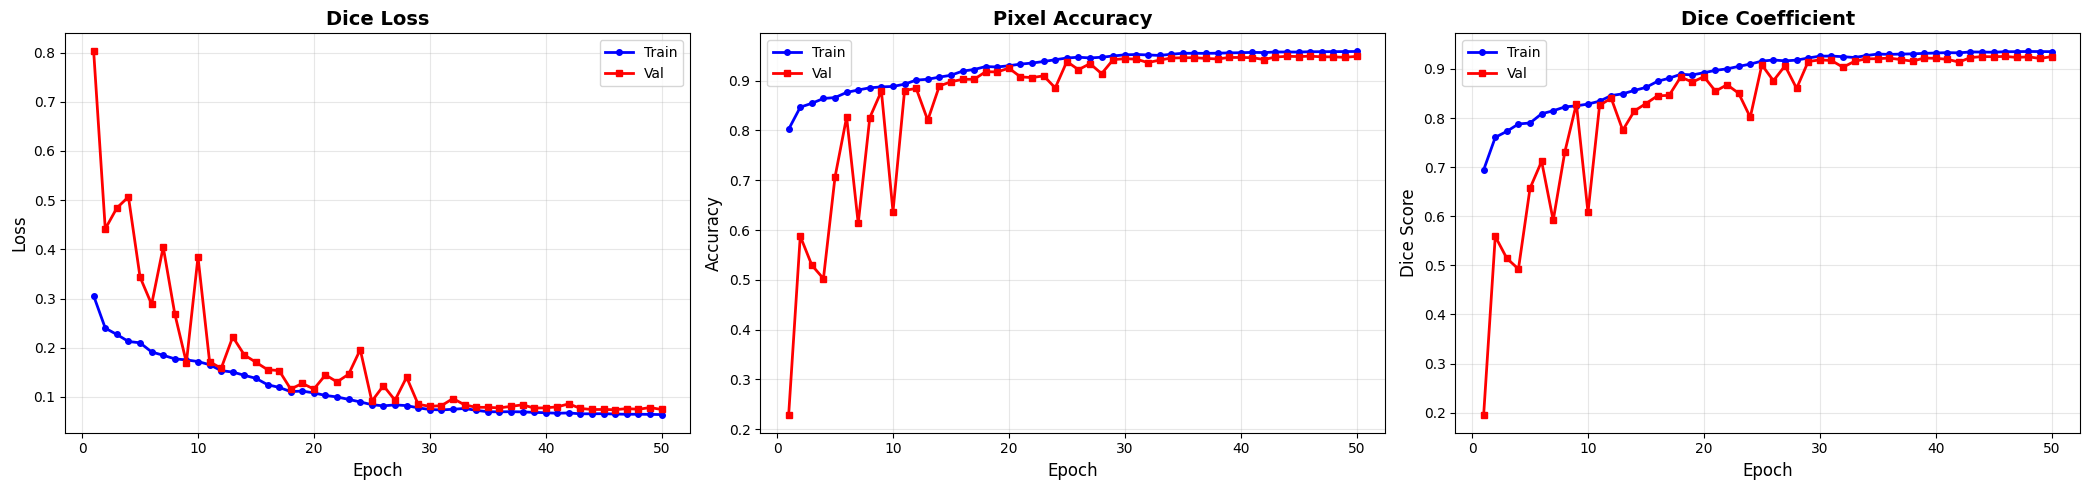

In [31]:
# Graficar historial detallado
plot_detailed_history(history)

### Convertir modelo a LiteRT 
(en este caso cuantización dinámica, pero puede ser otra)

In [33]:
# Cargar el modelo entrenado
model = tf.keras.models.load_model("best_model.keras", compile=False)

# Convertidor LiteRT
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Activar cuantización dinámica
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convertir
litert_model = converter.convert()

# Guardar archivo .tflite
with open("model_dynamic_quant.tflite", "wb") as f:
    f.write(litert_model)

INFO:tensorflow:Assets written to: /tmp/tmpop5jcbxs/assets


INFO:tensorflow:Assets written to: /tmp/tmpop5jcbxs/assets


Saved artifact at '/tmp/tmpop5jcbxs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 128, 128, 2), dtype=tf.float32, name=None)
Captures:
  135081057542672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081057543632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081057544016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081057543824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081057542864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081057545168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081057545552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081057545936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081057545744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081057538256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13508105754

W0000 00:00:1764658711.410913      47 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1764658711.410944      47 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1764658711.484294      47 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


### Comparación de modelos

In [42]:
# Cargar modelos
model_tf = tf.keras.models.load_model("best_model.keras", compile=False)

interpreter = tf.lite.Interpreter(model_path="model_dynamic_quant.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [43]:
# Función para inferencia LiteRT
def litert_predict(interpreter, input_data):
    # Set input
    interpreter.set_tensor(input_details[0]["index"], input_data)
    interpreter.invoke()
    # Get output
    output = interpreter.get_tensor(output_details[0]["index"])
    return output

In [44]:
def calculate_dice_coefficient(y_true, y_pred, smooth=1e-6):
    """
    Calcula el Dice Coefficient para máscaras de segmentación
    Args:
        y_true: Ground truth one-hot (B, H, W, C) o (H, W, C)
        y_pred: Predicciones one-hot (B, H, W, C) o (H, W, C)
        smooth: Factor de suavizado
    Returns:
        Dice coefficient (float)
    """
    y_true_f = y_true.reshape(-1, y_true.shape[-1])
    y_pred_f = y_pred.reshape(-1, y_pred.shape[-1])
    
    intersection = np.sum(y_true_f * y_pred_f, axis=0)
    union = np.sum(y_true_f, axis=0) + np.sum(y_pred_f, axis=0)
    
    dice = (2. * intersection + smooth) / (union + smooth)
    return np.mean(dice)

In [45]:
# Evaluar Dice Coefficient TF y LiteRT
dice_scores_tf = []
dice_scores_litert = []

start_tf = time.time()
for images, masks in test_loader:
    # Predicción TensorFlow
    preds_tf = model_tf.predict(images, verbose=0)  # Shape: (B, H, W, 2)
    
    # Calcular Dice para cada imagen del batch
    masks_np = masks.numpy()  # Ground truth one-hot (B, H, W, 2)
    
    for i in range(preds_tf.shape[0]):
        dice = calculate_dice_coefficient(masks_np[i], preds_tf[i])
        dice_scores_tf.append(dice)

end_tf = time.time()

# Dice Coefficient promedio TensorFlow
dice_tf = np.mean(dice_scores_tf)


# ----- LiteRT -----
start_litert = time.time()
for images, masks in test_loader:
    images_np = images.numpy()
    masks_np = masks.numpy()

    for i in range(images_np.shape[0]):
        inp = images_np[i:i+1].astype(np.float32)
        
        # Predicción LiteRT
        pred = litert_predict(interpreter, inp)  # Shape: (1, H, W, 2)
        
        # Calcular Dice
        dice = calculate_dice_coefficient(masks_np[i], pred[0])
        dice_scores_litert.append(dice)

end_litert = time.time()

# Dice Coefficient promedio LiteRT
dice_litert = np.mean(dice_scores_litert)

In [46]:
# Tiempos de inferencia
total_samples = len(dice_scores_tf)
tf_inference_time = (end_tf - start_tf) / total_samples
litert_inference_time = (end_litert - start_litert) / total_samples

In [47]:
# Tamaño de los modelos
size_tf = os.path.getsize("best_model.keras") / (1024 * 1024)
size_litert = os.path.getsize("model_dynamic_quant.tflite") / (1024 * 1024)

In [48]:
# Resultados
print("======= RESULTADOS =======")
print(f"Dice Coefficient TensorFlow:  {dice_tf:.4f}")
print(f"Dice Coefficient LiteRT:      {dice_litert:.4f}")
print(f"Diferencia Dice:              {abs(dice_tf - dice_litert):.4f}")
print()
print(f"Tiempo por inferencia TF:     {tf_inference_time*1000:.3f} ms")
print(f"Tiempo por inferencia LiteRT: {litert_inference_time*1000:.3f} ms")
print(f"Speedup:                      {tf_inference_time/litert_inference_time:.2f}x")
print()
print(f"Peso modelo TensorFlow:       {size_tf:.2f} MB")
print(f"Peso modelo LiteRT:           {size_litert:.2f} MB")
print(f"Reducción de tamaño:          {(1 - size_litert/size_tf)*100:.1f}%")
print("==========================")

======= RESULTADOS =======
Dice Coefficient TensorFlow:  0.9128
Dice Coefficient LiteRT:      0.9126
Diferencia Dice:              0.0002

Tiempo por inferencia TF:     75.769 ms
Tiempo por inferencia LiteRT: 158.076 ms
Speedup:                      0.48x

Peso modelo TensorFlow:       164.56 MB
Peso modelo LiteRT:           13.78 MB
Reducción de tamaño:          91.6%
